# 6. Modelos de clasificación 

In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

In [2]:
train_path = r'train_clean.csv'
train = pd.read_csv(train_path)

In [3]:
train[['text', 'text_clean', 'target']].head()

,text,text_clean,target
0,Our Deeds are the Reason of this #earthquake M...,deed reason earthquake may allah forgive u,1
1,Forest fire near La Ronge Sask. Canada,forest fire near la ronge sask canada,1
2,All residents asked to 'shelter in place' are ...,resident ask shelter place notify officer evac...,1
3,"13,000 people receive #wildfires evacuation or...",people receive wildfire evacuation order calif...,1
4,Just got sent this photo from Ruby #Alaska as ...,get sent photo ruby alaska smoke wildfires pou...,1


In [4]:
X = train['text_clean']
y = train['target']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.3, random_state = 42, stratify = y)

In [5]:
vectorizer = TfidfVectorizer(ngram_range = (1 , 2) )
X_train_tfidf = vectorizer.fit_transform(X_train )
X_test_tfidf = vectorizer.transform(X_test )

In [6]:
modelo_lr = LogisticRegression(random_state = 42 , max_iter= 200 )
modelo_lr.fit(X_train_tfidf, y_train )
y_pred_lr = modelo_lr.predict(X_test_tfidf )

modelo_nb = MultinomialNB()
modelo_nb.fit(X_train_tfidf, y_train )
y_pred_nb = modelo_nb.predict(X_test_tfidf )

modelo_rf = RandomForestClassifier(random_state = 42, n_estimators = 100 )
modelo_rf.fit(X_train_tfidf, y_train )
y_pred_rf = modelo_rf.predict(X_test_tfidf )

In [7]:
resultados_modelos = pd.DataFrame({
    'Modelo': ['LogisticRegression', 'MultinomialNB', 'RandomForestClassifier'],
    'Accuracy': [ accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred_nb),
        accuracy_score(y_test, y_pred_rf) ],
    'Precision': [ precision_score(y_test, y_pred_lr),
        precision_score(y_test, y_pred_nb),
        precision_score(y_test, y_pred_rf) ] ,
    'Recall': [ recall_score(y_test, y_pred_lr),
        recall_score(y_test, y_pred_nb),
        recall_score(y_test, y_pred_rf) ] ,
    'F1-Score': [ f1_score(y_test, y_pred_lr),
        f1_score(y_test, y_pred_nb),
        f1_score(y_test, y_pred_rf) ]
})

resultados_modelos = resultados_modelos.sort_values('F1-Score' , ascending= False )
resultados_modelos

,Modelo,Accuracy,Precision,Recall,F1-Score
0,LogisticRegression,0.805166,0.834165,0.681957,0.750421
1,MultinomialNB,0.807356,0.863087,0.655454,0.745075
2,RandomForestClassifier,0.791594,0.823303,0.655454,0.729852


In [8]:
mejor_modelo_nombre = resultados_modelos.iloc[0]['Modelo' ]
mejor_modelo_nombre

'LogisticRegression'

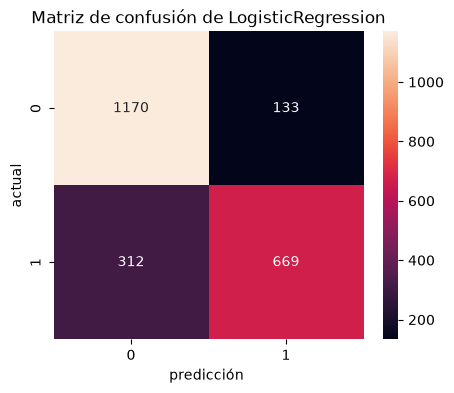

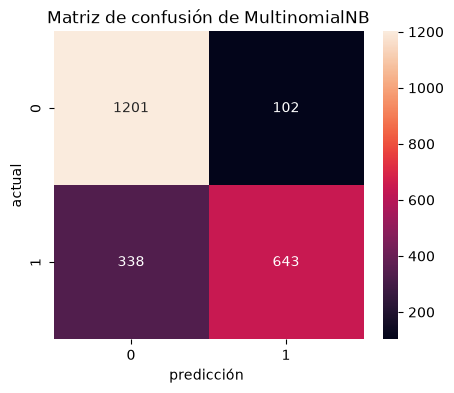

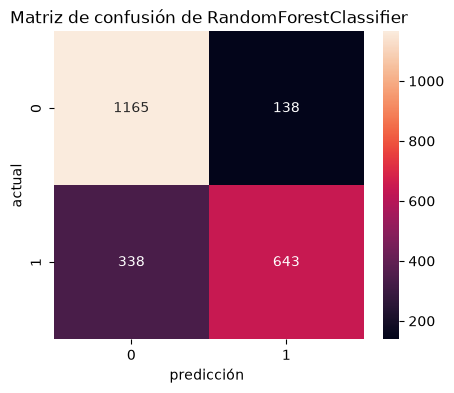

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

cm_lr = confusion_matrix(y_test, y_pred_lr)
plt.figure(figsize=(5, 4))
sns.heatmap(cm_lr, annot = True, fmt = 'd')
plt.title('Matriz de confusión de LogisticRegression')
plt.ylabel('actual')
plt.xlabel('predicción ')
plt.show()

cm_nb = confusion_matrix(y_test, y_pred_nb)
plt.figure(figsize = (5 , 4) )
sns.heatmap(cm_nb, annot = True , fmt = 'd' ) 
plt.title('Matriz de confusión de MultinomialNB')
plt.ylabel('actual')
plt.xlabel('predicción ')
plt.show()

cm_rf = confusion_matrix(y_test, y_pred_rf)
plt.figure(figsize = (5 , 4) )
sns.heatmap(cm_rf, annot = True , fmt = 'd')
plt.title('Matriz de confusión de RandomForestClassifier')
plt.ylabel('actual')
plt.xlabel('predicción ')
plt.show()

# 7 función para que el usuario clasifique un tweet

In [10]:
import re
import html
import string
import nltk
from nltk.corpus import stopwords, wordnet
from nltk.stem import WordNetLemmatizer
from nltk import pos_tag

nltk.download('stopwords' )
nltk.download('wordnet' )
nltk.download('omw-1.4' )
nltk.download('averaged_perceptron_tagger_eng' )

stop_words = set(stopwords.words('english' ) )
lemmatizer = WordNetLemmatizer()

def quitar_urls(texto):
    return re.sub(r'http\S+|www\.\S+', '', texto)

def quitar_arroba_hashtag(texto):
    texto = re.sub(r'@\w+', '', texto )
    texto = re.sub(r'#', '', texto )
    return texto

def quitar_emojis(texto):
    patron_emoji = re.compile(
        "["
        "\U0001F600-\U0001F64F"
        "\U0001F300-\U0001F5FF"
        "\U0001F680-\U0001F6FF"
        "\U0001F1E0-\U0001F1FF"
        "\U00002700-\U000027BF"
        "\U0001F900-\U0001F9FF"
        "]+" ,

        flags = re.UNICODE
    )
    return patron_emoji.sub('', texto)

def quitar_puntuacion(texto):
    return texto.translate(str.maketrans('', '', string.punctuation))

def quitar_numeros(texto, conservar_911 = True ):
    if conservar_911: texto = texto.replace('911', 'EMERGENCIA911TOKEN')

    texto = re.sub(r'\d+', '', texto)

    if conservar_911: texto = texto.replace( 'EMERGENCIA911TOKEN', '911')
    return texto

def quitar_stopwords(texto):
    palabras = texto.split()
    palabras_filtradas = [ p for p in palabras if p not in stop_words]
    return ' '.join(palabras_filtradas)

def normalizar_repeticiones(texto):
    return re.sub(r'(.)\1{2,}', r'\1\1', texto)

def quitar_letras_sueltas(texto): return ' '.join([p for p in texto.split() if len(p) > 1])

def obtener_pos_wordnet(tag):
    if tag.startswith('J'): return wordnet.ADJ
    elif tag.startswith('V'): return wordnet.VERB
    elif tag.startswith('N'): return wordnet.NOUN
    elif tag.startswith('R'): return wordnet.ADV
    else: return wordnet.NOUN

def aplicar_lematizacion(texto):
    palabras = texto.split()
    tags = pos_tag(palabras)

    lematizadas = [ lemmatizer.lemmatize(palabra, obtener_pos_wordnet(tag)) for palabra, tag in tags ]

    return ' '.join(lematizadas)

def preprocesar_tweet(texto):
    texto = texto.lower()
    texto = quitar_urls(texto)
    texto = quitar_arroba_hashtag(texto)
    texto = quitar_emojis(texto)
    texto = quitar_puntuacion(texto)
    texto = quitar_numeros(texto)
    texto = quitar_stopwords(texto)
    
    texto = texto.strip().replace('\n', ' ')
    texto = re.sub(r'\s+', ' ', texto )
    texto = html.unescape(texto)
    texto = normalizar_repeticiones(texto)
    texto = quitar_letras_sueltas(texto)
    texto = aplicar_lematizacion(texto)

    return texto

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\darta\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping corpora\stopwords.zip.
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\darta\AppData\Roaming\nltk_data...
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\darta\AppData\Roaming\nltk_data...
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     C:\Users\darta\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping taggers\averaged_perceptron_tagger_eng.zip.


In [11]:
def clasificar_tweet(tweet):
    tweet_limpio = preprocesar_tweet(tweet)
    tweet_tfidf = vectorizer.transform([tweet_limpio])
    prediccion = modelo_lr.predict(tweet_tfidf)[0]

    if prediccion == 1: return "Desastre real"
    else: return "No desastre"

In [12]:
tweets_prueba = [
    "There is a huge wildfire spreading near the city",
    "I love this beautiful sunny day",
    "Emergency evacuation after massive flooding",
    "I'm going to watch a movie tonight"
]

for tweet in tweets_prueba:
    print("Tweet:", tweet)
    print("Clasificación:", clasificar_tweet(tweet))
    print()

Tweet: There is a huge wildfire spreading near the city
Clasificación: Desastre real

Tweet: I love this beautiful sunny day
Clasificación: No desastre

Tweet: Emergency evacuation after massive flooding
Clasificación: Desastre real

Tweet: I'm going to watch a movie tonight
Clasificación: No desastre



testearlo manualmente

In [13]:
print("Clasificador de Tweets")
print("")
print("Escribe un tweet en inglés para determinar si se refiere a un desastre real.")
print("Escribe 'salir' para finalizar ")
print("")

while True:
    tweet_usuario = input("\nIngrese un tweet: ")

    if tweet_usuario.lower() == "salir":
        print("Clasificador finalizado.")
        break

    if tweet_usuario.strip() == "":
        print("Por favor, ingrese un tweet válido.")
        continue

    resultado = clasificar_tweet(tweet_usuario)

    print("Tweet ingresado:", tweet_usuario)
    print("Resultado:", resultado)
    print("------------")

Clasificador de Tweets

Escribe un tweet en inglés para determinar si se refiere a un desastre real.
Escribe 'salir' para finalizar 

Tweet ingresado: theres a shooting in the school near my house 
Resultado: Desastre real
------------
Tweet ingresado: bombing in cisjordania, breaks the peace ceasefire
Resultado: Desastre real
------------
Tweet ingresado: i like cats
Resultado: No desastre
------------
Tweet ingresado: ormuz is again closed by iranian armed forces, USA responds with ships
Resultado: No desastre
------------
Tweet ingresado: ormuz is again closed by iranian armed forces with ship attacks, USA responds with warships and tomahawks
Resultado: Desastre real
------------
Por favor, ingrese un tweet válido.
Por favor, ingrese un tweet válido.
Clasificador finalizado.


# 8. Positividad-Negatividad de los tweets

In [ ]:
# 8. Clasificación de palabras positivas, negativas o neutras

import nltk
nltk.download('vader_lexicon')
from nltk.sentiment import SentimentIntensityAnalyzer

sia = SentimentIntensityAnalyzer()

def analizar_sentimiento(texto):
    """
    Usa VADER sobre el texto original (conserva mayúsculas, signos y
    emojis,  aportan señal de sentimiento).
    """
    return sia.polarity_scores(texto)

# Se usa train['text'] (texto original) y no text_clean, porque VADER
# se beneficia de mayúsculas, puntuación y emoticones ya eliminados en el preprocesamiento.
sentimientos = train['text'].apply(analizar_sentimiento)

train['sent_neg'] = sentimientos.apply(lambda d: d['neg'])
train['sent_neu'] = sentimientos.apply(lambda d: d['neu'])
train['sent_pos'] = sentimientos.apply(lambda d: d['pos'])
train['sent_compound'] = sentimientos.apply(lambda d: d['compound'])

def clasificar_sentimiento(compound):
    if compound >= 0.05:
        return 'positivo'
    elif compound <= -0.05:
        return 'negativo'
    else:
        return 'neutro'

train['sentimiento'] = train['sent_compound'].apply(clasificar_sentimiento)
train[['text', 'sent_compound', 'sentimiento']].head(10)

[nltk_data] Downloading package vader_lexicon to
[nltk_data]     C:\Users\darta\AppData\Roaming\nltk_data...


,text,sent_compound,sentimiento
0,Our Deeds are the Reason of this #earthquake M...,0.2732,positivo
1,Forest fire near La Ronge Sask. Canada,-0.3400,negativo
2,All residents asked to 'shelter in place' are ...,-0.2960,negativo
3,"13,000 people receive #wildfires evacuation or...",0.0000,neutro
4,Just got sent this photo from Ruby #Alaska as ...,0.0000,neutro
5,#RockyFire Update => California Hwy. 20 closed...,-0.3400,negativo
6,#flood #disaster Heavy rain causes flash flood...,0.0000,neutro
7,I'm on top of the hill and I can see a fire in...,-0.1531,negativo
8,There's an emergency evacuation happening now ...,-0.3818,negativo
9,I'm afraid that the tornado is coming to our a...,0.0000,neutro


In [15]:
print(train['sentimiento'].value_counts())
print()
print(pd.crosstab(train['target'], train['sentimiento'], normalize='index'))

sentimiento
negativo    3707
neutro      2013
positivo    1893
Name: count, dtype: int64

sentimiento  negativo    neutro  positivo
target                                   
0            0.425150  0.260940  0.313911
1            0.568939  0.269031  0.162030


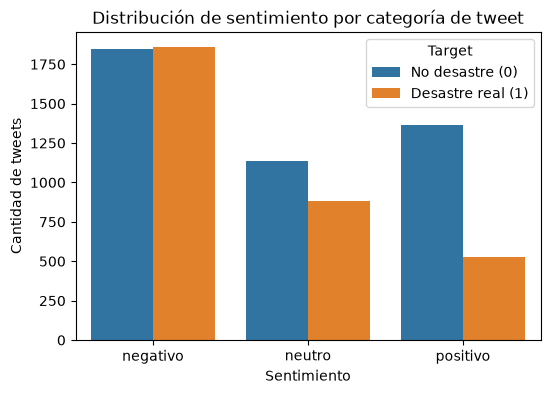

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6, 4))
sns.countplot(data=train, x='sentimiento', hue='target', order=['negativo', 'neutro', 'positivo'])
plt.title('Distribución de sentimiento por categoría de tweet')
plt.xlabel('Sentimiento')
plt.ylabel('Cantidad de tweets')
plt.legend(title='Target', labels=['No desastre (0)', 'Desastre real (1)'])
plt.show()

# 9. Los 10 Tweets más negativos y 10 más positivos

In [ ]:
# 9. Tweets más negativos / positivos

top10_negativos = train.sort_values('sent_compound', ascending=True).head(10)
top10_positivos = train.sort_values('sent_compound', ascending=False).head(10)

print("TOP 10 TWEETS MÁS NEGATIVOS")
print(top10_negativos[['text', 'sent_compound', 'target']].to_string(index=False))

print("\nvTOP 10 TWEETS MÁS POSITIVOS")
print(top10_positivos[['text', 'sent_compound', 'target']].to_string(index=False))

=== TOP 10 TWEETS MÁS NEGATIVOS ===
                                                                                                                                           text  sent_compound  target
                                                                wreck? wreck wreck wreck wreck wreck wreck wreck wreck wreck wreck wreck wreck?        -0.9883       0
  @Abu_Baraa1 Suicide bomber targets Saudi mosque at least 13 dead - Suicide bomber targets Saudi mosque at least 13 dead\r\nThis is ridiculous        -0.9686       1
   Suicide bomber kills 15 in Saudi security site mosque - A suicide bomber killed at least 15 people in an attack on... http://t.co/FY0r9o7Xsl        -0.9623       1
    ? 19th Day Since 17-Jul-2015 -- Nigeria: Suicide Bomb Attacks Killed 64 People; Blamed: Boko Haram [L.A. Times/AP] | http://t.co/O2cdKpSDfp        -0.9595       1
17 killed in SÛªArabia mosque suicide bombing\r\n\r\nA suicide bomber attacked a mosque in Aseer south-western Saudi... http://t

In [18]:
print("Distribución de target en el top 10 más negativos:")
print(top10_negativos['target'].value_counts())

print("\nDistribución de target en el top 10 más positivos:")
print(top10_positivos['target'].value_counts())

Distribución de target en el top 10 más negativos:
target
1    8
0    2
Name: count, dtype: int64

Distribución de target en el top 10 más positivos:
target
0    8
1    2
Name: count, dtype: int64


Promedio de sent_compound por categoría:
target
0   -0.060607
1   -0.264571
Name: sent_compound, dtype: float64


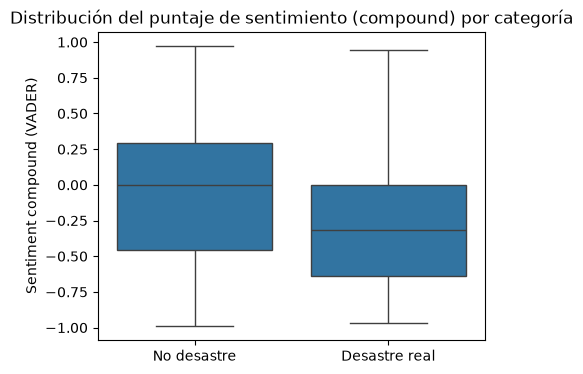

In [19]:
promedio_compound = train.groupby('target')['sent_compound'].mean()
print("Promedio de sent_compound por categoría:")
print(promedio_compound)

plt.figure(figsize=(5, 4))
sns.boxplot(data=train, x='target', y='sent_compound')
plt.xticks([0, 1], ['No desastre', 'Desastre real'])
plt.title('Distribución del puntaje de sentimiento (compound) por categoría')
plt.ylabel('Sentiment compound (VADER)')
plt.xlabel('')
plt.show()

In [ ]:
#Prueba estadística para ver si son realmente distintos

from scipy import stats

compound_desastre = train[train['target'] == 1]['sent_compound']
compound_no_desastre = train[train['target'] == 0]['sent_compound']

t_stat, p_valor = stats.ttest_ind(compound_desastre, compound_no_desastre, equal_var=False)
print(f"t-statistic: {t_stat:.4f}, p-valor: {p_valor:.4f}")

if p_valor < 0.05:
    print("La diferencia de sentimiento entre categorías es estadísticamente significativa.")
else:
    print("No hay evidencia suficiente de diferencia significativa entre categorías.")

t-statistic: -19.9456, p-valor: 0.0000
La diferencia de sentimiento entre categorías es estadísticamente significativa.


# 10. Variable de negatividad

In [ ]:
# 10. Variable de "negatividad" y reentrenamiento del modelo
train['negatividad'] = train['sent_neg']
train[['text', 'sent_compound', 'negatividad']].head(10)

,text,sent_compound,negatividad
0,Our Deeds are the Reason of this #earthquake M...,0.2732,0.000
1,Forest fire near La Ronge Sask. Canada,-0.3400,0.286
2,All residents asked to 'shelter in place' are ...,-0.2960,0.095
3,"13,000 people receive #wildfires evacuation or...",0.0000,0.000
4,Just got sent this photo from Ruby #Alaska as ...,0.0000,0.000
5,#RockyFire Update => California Hwy. 20 closed...,-0.3400,0.130
6,#flood #disaster Heavy rain causes flash flood...,0.0000,0.000
7,I'm on top of the hill and I can see a fire in...,-0.1531,0.158
8,There's an emergency evacuation happening now ...,-0.3818,0.191
9,I'm afraid that the tornado is coming to our a...,0.0000,0.000


In [ ]:
from scipy.sparse import hstack, csr_matrix


negatividad_train = train.loc[X_train.index, 'negatividad'].values.reshape(-1, 1)
negatividad_test = train.loc[X_test.index, 'negatividad'].values.reshape(-1, 1)

X_train_tfidf_neg = hstack([X_train_tfidf, csr_matrix(negatividad_train)])
X_test_tfidf_neg = hstack([X_test_tfidf, csr_matrix(negatividad_test)])

print("Shape original TF-IDF:", X_train_tfidf.shape)
print("Shape con variable de negatividad:", X_train_tfidf_neg.shape)

Shape original TF-IDF: (5329, 42472)
Shape con variable de negatividad: (5329, 42473)


In [23]:
modelo_lr_neg = LogisticRegression(random_state=42, max_iter=200)
modelo_lr_neg.fit(X_train_tfidf_neg, y_train)
y_pred_lr_neg = modelo_lr_neg.predict(X_test_tfidf_neg)

comparacion = pd.DataFrame({
    'Métrica': ['Accuracy', 'Precision', 'Recall', 'F1-Score'],
    'Modelo original': [
        accuracy_score(y_test, y_pred_lr),
        precision_score(y_test, y_pred_lr),
        recall_score(y_test, y_pred_lr),
        f1_score(y_test, y_pred_lr)
    ],
    'Modelo + negatividad': [
        accuracy_score(y_test, y_pred_lr_neg),
        precision_score(y_test, y_pred_lr_neg),
        recall_score(y_test, y_pred_lr_neg),
        f1_score(y_test, y_pred_lr_neg)
    ]
})
comparacion['Diferencia'] = comparacion['Modelo + negatividad'] - comparacion['Modelo original']
comparacion

,Métrica,Modelo original,Modelo + negatividad,Diferencia
0,Accuracy,0.805166,0.802977,-0.002189
1,Precision,0.834165,0.829814,-0.004351
2,Recall,0.681957,0.680938,-0.001019
3,F1-Score,0.750421,0.748040,-0.002380


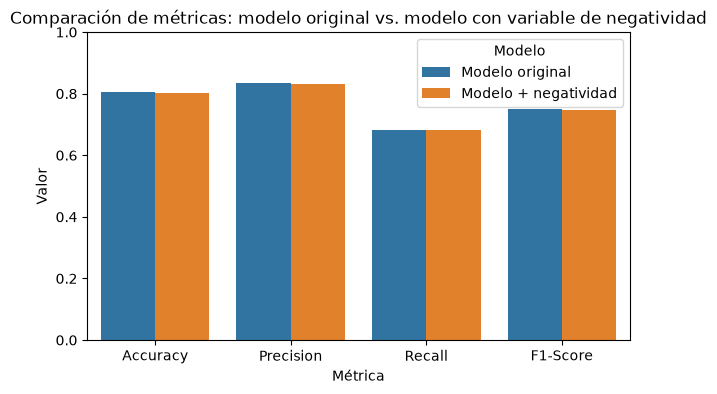

In [24]:
comparacion_plot = comparacion.melt(id_vars='Métrica', value_vars=['Modelo original', 'Modelo + negatividad'],
                                     var_name='Modelo', value_name='Valor')

plt.figure(figsize=(7, 4))
sns.barplot(data=comparacion_plot, x='Métrica', y='Valor', hue='Modelo')
plt.title('Comparación de métricas: modelo original vs. modelo con variable de negatividad')
plt.ylim(0, 1)
plt.show()

Prácticamente, no cambió. Porque lo que determina si algo es desastre o no no es la "negatividad" de las oraciones, sino las palabras en sí que se usan en dichas oraciones. 